In [1]:
%load_ext autoreload
%autoreload 2

In [63]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

(141, 1024)


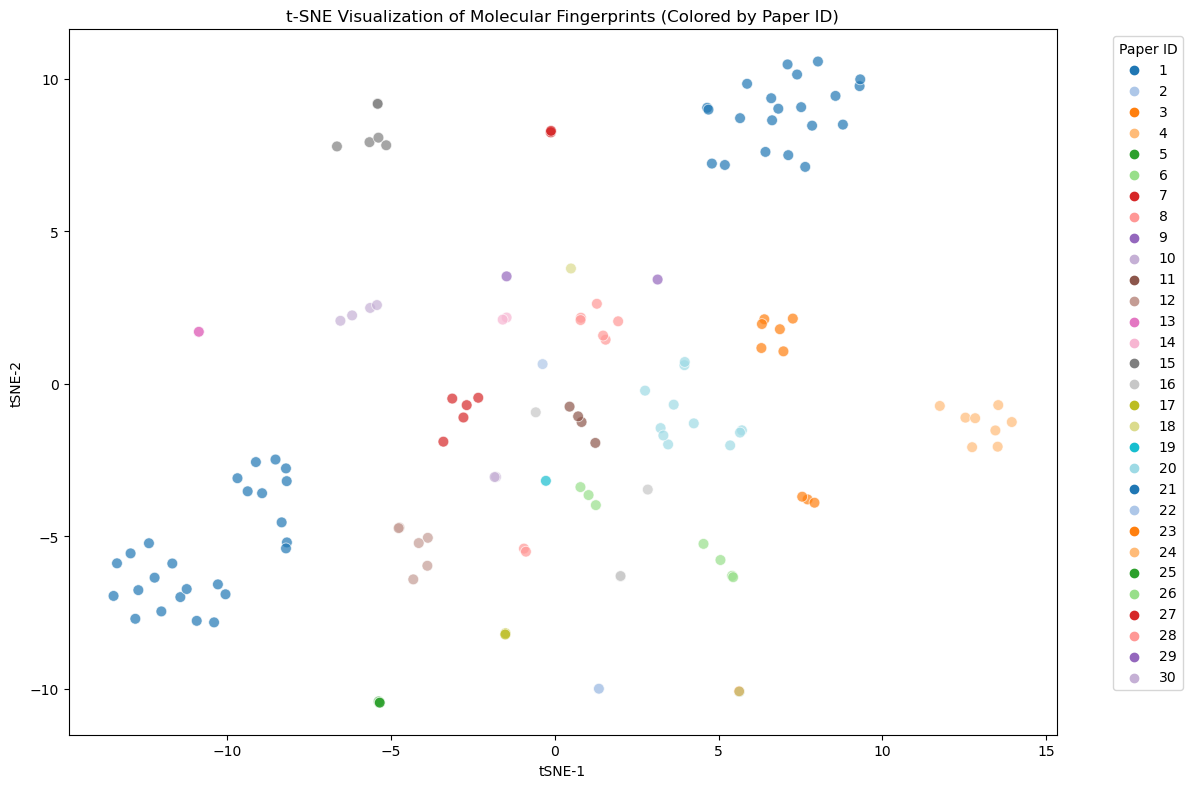

In [ ]:

JMC = pd.read_csv('SMILES_from_JMC.csv')
paper_ids = JMC['Paper ID']
smiles_list = JMC['SMILES_pro']

# generate FP from SMILES
smiles_list = JMC['SMILES_pro']
fps = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(smi), 2, 1024) for smi in smiles_list]
fp_array = np.stack([np.array(fp) for fp in fps])

print(fp_array.shape)  # (n_samples, n_bits)

#tsne
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(fp_array)

tsne_df = pd.DataFrame(tsne_result, columns=['tSNE-1', 'tSNE-2'])
tsne_df['Paper ID'] = paper_ids

plt.figure(figsize=(12, 8))
sns.scatterplot(x='tSNE-1', y='tSNE-2', hue='Paper ID', data=tsne_df, palette='tab20', alpha=0.7, s=60)
plt.title("t-SNE Visualization of Molecular Fingerprints (Colored by Paper ID)")
plt.legend(title='Paper ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 筛选后分子分布

In [14]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:

# 

JMC = pd.read_csv('SMILES_from_JMC.csv')

sampled_df = JMC.groupby('Paper ID').apply(lambda x: x.sample(n=min(2, len(x)), random_state=42)).reset_index(drop=True)

#sampled_df.to_csv('JMC_benchmark.csv',index=False)

(53, 1024)


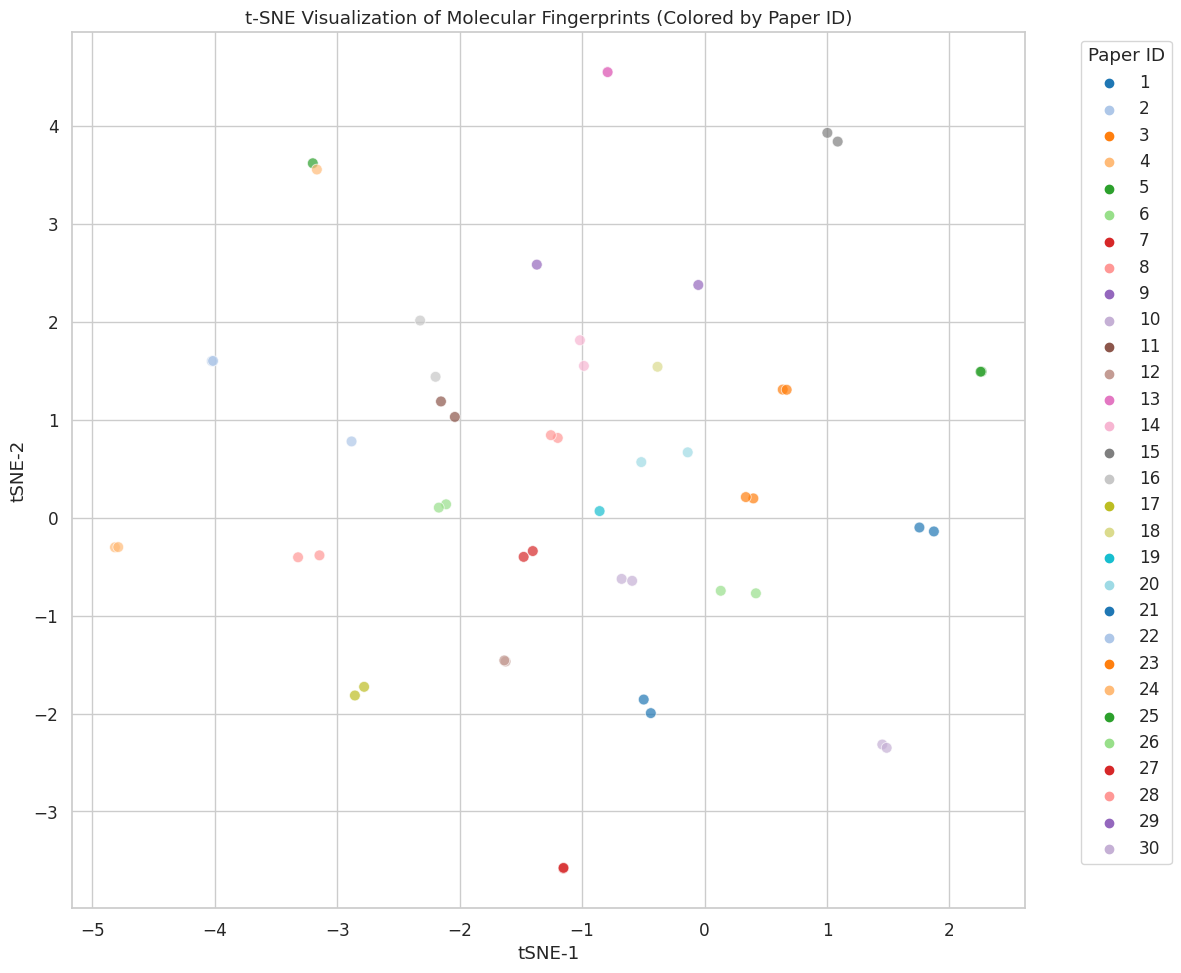

In [ ]:
paper_ids = sampled_df['Paper ID']
smiles_list = sampled_df['SMILES_pro']

# generate FP from SMILES
smiles_list = sampled_df['SMILES_pro']
fps = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(smi), 2, 1024) for smi in smiles_list]


fp_array = np.stack([np.array(fp) for fp in fps])

print(fp_array.shape)  # (n_samples, n_bits)

#tsne
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(fp_array)

tsne_df = pd.DataFrame(tsne_result, columns=['tSNE-1', 'tSNE-2'])
tsne_df['Paper ID'] = paper_ids

plt.figure(figsize=(12, 10))
sns.scatterplot(x='tSNE-1', y='tSNE-2', hue='Paper ID', data=tsne_df, palette='tab20', alpha=0.7, s=60)
plt.title("t-SNE Visualization of Molecular Fingerprints (Colored by Paper ID)")
plt.legend(title='Paper ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

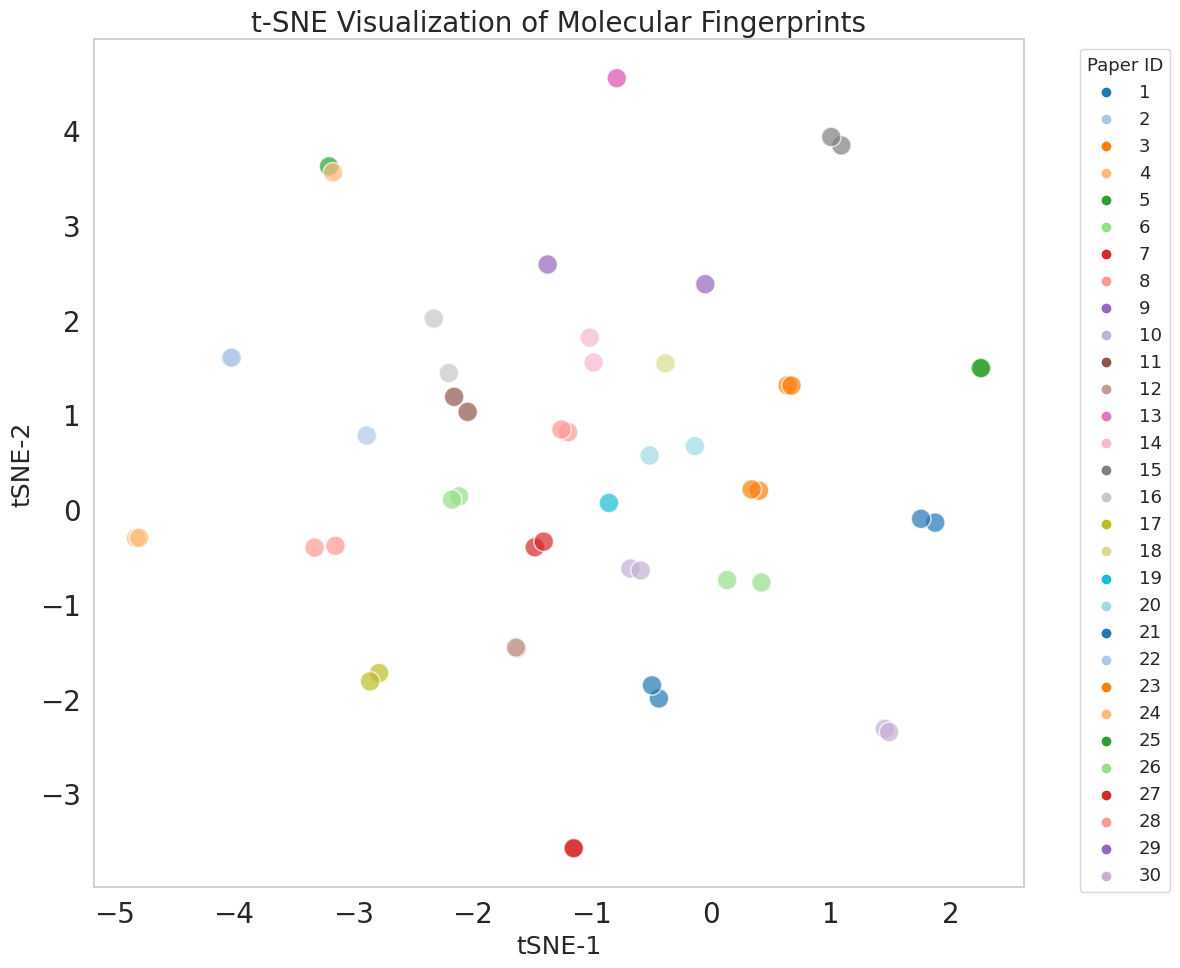

In [ ]:
# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(fp_array)

tsne_df = pd.DataFrame(tsne_result, columns=['tSNE-1', 'tSNE-2'])
tsne_df['Paper ID'] = paper_ids


plt.figure(figsize=(12, 10))
ax = sns.scatterplot(
    x='tSNE-1', y='tSNE-2',
    hue='Paper ID',
    data=tsne_df,
    palette='tab20',
    alpha=0.7,
    s=200
)


ax.set_xlabel('tSNE-1', fontsize=18)           
ax.set_ylabel('tSNE-2', fontsize=18)         
ax.tick_params(axis='both', which='major', labelsize=20)  


ax.grid(False)  


plt.title("t-SNE Visualization of Molecular Fingerprints", fontsize=20)
plt.legend(title='Paper ID', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=13, title_fontsize=13)


plt.tight_layout()
plt.show()

In [ ]:
from rdkit.Chem import Descriptors
from rdkit import Chem
import pandas as pd
from rdkit.Contrib.SA_Score import sascorer

sampled_df = pd.read_csv('JMC_benchmark.csv')


mols = [Chem.MolFromSmiles(smile) for smile in sampled_df['SMILES_pro']]
descrs = [Descriptors.CalcMolDescriptors(mol) for mol in mols]
smiles_descrs = pd.DataFrame(descrs)

sas_list = [sascorer.calculateScore(mol) for mol in mols]

smiles_descrs.insert(0, 'SAS', sas_list)
smiles_descrs.insert(0, 'SMILES_pro', sampled_df['SMILES_pro'])
smiles_descrs.insert(0, 'Paper ID', sampled_df['Paper ID'])

smiles_descrs.to_csv('benchmark/JMC_mol_descrs.csv')

In [23]:
mol_descrs = pd.read_csv('benchmark/JMC_mol_descrs.csv')
mol_descrs[['MolLogP','MolWt','qed','TPSA','SAS','HeavyAtomCount']]

,MolLogP,MolWt,qed,TPSA,SAS,HeavyAtomCount
0,2.52690,476.621,0.670264,76.12,3.086443,35
1,4.18630,556.751,0.535201,76.12,3.851792,41
2,5.05050,475.555,0.606488,36.02,2.438060,34
3,3.28612,364.449,0.532474,79.30,2.323881,27
4,3.37842,378.432,0.552830,96.37,2.348274,28
5,4.56320,523.102,0.413335,81.31,3.566681,36
6,5.19190,636.262,0.279865,101.62,3.634601,44
7,-1.31092,1154.200,0.030867,362.89,5.469971,82
8,3.98540,329.407,0.577493,59.97,2.462930,25
9,4.07600,317.352,0.493583,88.85,2.354198,24


Available columns: ['Unnamed: 0', 'Paper ID', 'SMILES_pro', 'SAS', 'MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', '

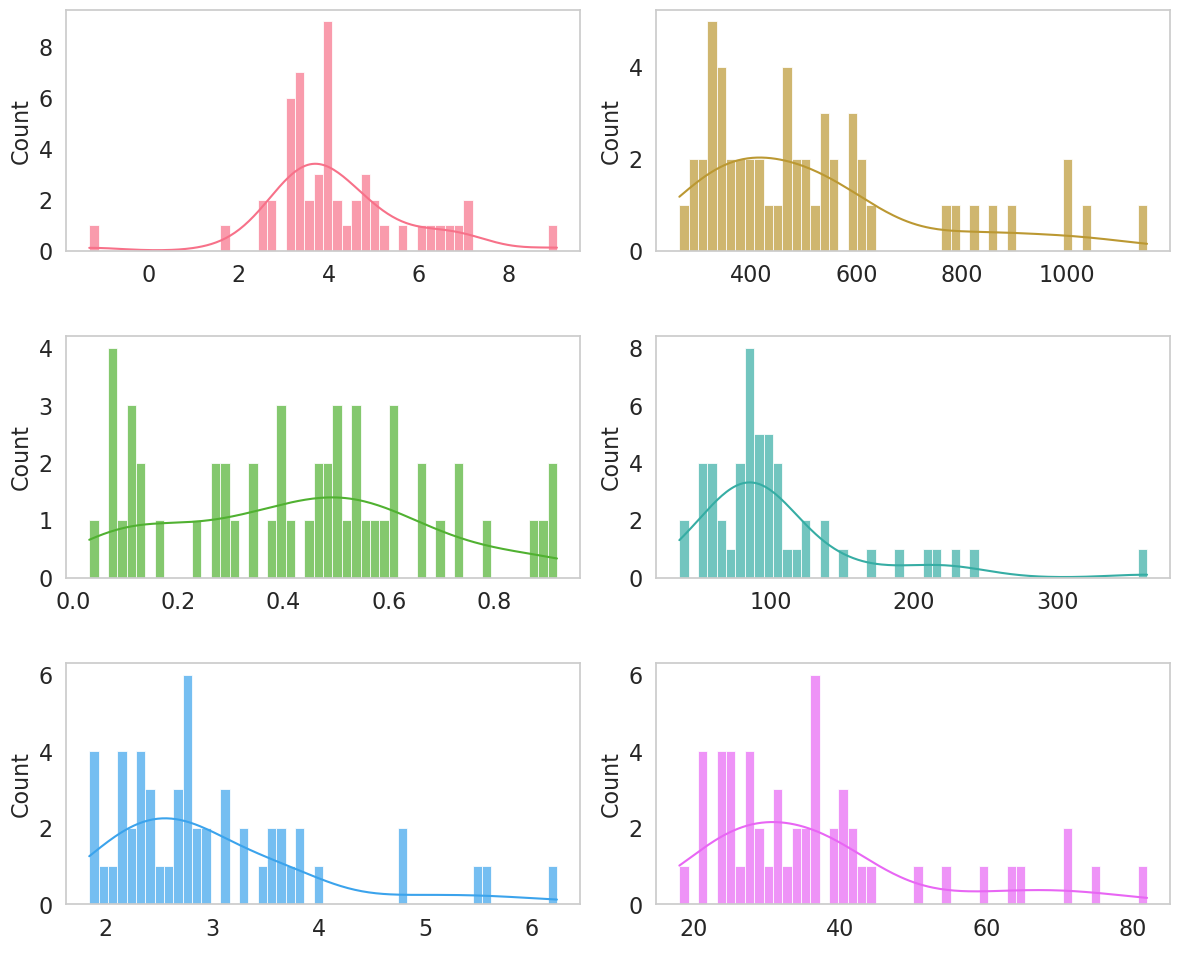

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid", font_scale=1.1)
plt.rcParams['font.family'] = 'DejaVu Sans'


mol_descrs = pd.read_csv('benchmark/JMC_mol_descrs.csv')

print("Available columns:", mol_descrs.columns.tolist())


property_map = {
    'MolLogP': 'LogP',
    'MolWt': 'Molecular Weight',        
    'qed': 'QED',         
    'TPSA': 'TPSA',
    'SAS': 'SAS',
    'HeavyAtomCount': 'Heavy Atom Count'  # 新增
}


actual_columns = {
    'MolLogP': 'MolLogP',
    'MolWt': 'ExactMolWt',  
    'qed': 'qed',            
    'TPSA': 'TPSA',
    'SAS': 'SAS',
    'HeavyAtomCount': 'HeavyAtomCount'  }

# 提取所需列
selected_data = mol_descrs[[actual_columns[col] for col in property_map.keys()]].copy()

# 重命名为更友好的名字
selected_data.rename(columns=dict(zip(actual_columns.values(), property_map.values())), inplace=True)

# 去除无效值
selected_data.dropna(inplace=True)

print("\n📊 各分子性质的基础统计信息：")
stats = selected_data.describe().round(3)
print(stats)



fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()


properties = list(property_map.values())  # ['LogP', 'MW', 'QED', 'TPSA', 'SAS', 'Heavy Atom Count']

units = {
    'LogP': '',
    'Molecular Weight': '',
    'QED': '',
    'TPSA': '',
    'SAS': '',
    'Heavy Atom Count': ''  
}

name = ['(a)','(b)','(c)','(d)','(e)','(f)']
colors = sns.color_palette("husl", len(properties))

for i, prop in enumerate(properties):
    ax = axes[i]
    data = selected_data[prop].dropna()
    

    sns.histplot(data, bins=50, kde=True, ax=ax, color=colors[i], alpha=0.7)

    ax.set_xlabel(f"{' '}", fontsize=18)
    #ax.grid(True, linestyle='--', alpha=0.6)
    ax.grid(False)


    ax.set_ylabel('Count',fontsize=16) 
    
    ax.tick_params(axis='both', which='major', labelsize=16)  

plt.tight_layout()
plt.show()
